In [1]:
# モジュール
import numpy as np
import random
import sys
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.setrecursionlimit(100000000)

In [13]:
# スペック部分
class spec:
    #通常2000回転やって収支を出す
    def __init__(self,a,b,c,d,e):
        self.kaitensuu = a #現在の累計回転数
        self.all = b # 累計回転
        self.balls = c # 現在の出玉
        self.border = d # 1kあたりの回転
        self.limit = e
        self.max = 0 # 最大出玉
        self.min = 0

    def normal(self):
        limit = self.limit #回転数上限
        cost = 250 / self.border # 1回転あたりのコスト
        while True:
            if self.all > limit or self.max-self.min > 96000:
                return self.balls
            x = random.random()
            self.kaitensuu += 1
            self.balls -= cost
            if self.balls < self.min:
                self.min = self.balls
            self.all += 1
            if x <= 1/199.9*0.3:
                self.kaitensuu = 0
                self.balls += 280
                self.normal()
            elif x <= 1/199.9*0.99:
                self.kaitensuu = 0
                self.balls += 280
                self.rush()
            elif x <= 1/199.9:
                self.kaitensuu = 0
                self.balls += 1400
                self.LT(next = True)

    def rush(self):
        x = np.random.geometric(1/59.9)
        if x <= 54:
            x = random.random()
            if x < 0.3:
                self.kaitensuu = 0
                self.balls += 280
                self.rush()
            elif x <0.7:
                self.kaitensuu = 0
                self.balls += 1400
                self.rush()
            elif x < 0.97:
                self.kaitensuu = 0
                self.balls += 1400
                self.LT(next = False)
            else:
                self.kaitensuu = 0
                self.balls += 1400
                self.LT(next = True)
        else:
            self.kaitensuu = 0
            self.normal()

    def LT(self,next):
        if next:
            furiwake = random.random()
            if furiwake < 0.3:
                self.kaitensuu = 0
                self.balls += 280
                self.LT(next = False)
            elif furiwake < 0.775:
                self.kaitensuu = 0
                self.balls += 1400
                self.LT(next = False)
            else:
                self.kaitensuu = 0
                self.balls += 1400
                self.LT(next = True)
        elif next == False:
            x = np.random.geometric(1/59.9)
            if x <= 115:
                furiwake = random.random()
                if furiwake < 0.3:
                    self.kaitensuu = 0
                    self.balls += 280
                    self.LT(next = False)
                elif furiwake < 0.775:
                    self.kaitensuu = 0
                    self.balls += 1400
                    self.LT(next = False)
                else:
                    self.kaitensuu = 0
                    self.balls += 1400
                    self.LT(next= True)
            elif x <=119:
                furiwake = random.random()
                if furiwake < 0.3:
                    self.kaitensuu = 0
                    self.balls += 280
                    self.rush()
                elif furiwake < 0.7:
                    self.kaitensuu = 0
                    self.balls += 1400
                    self.rush()
                elif furiwake < 0.97:
                    self.kaitensuu = 0
                    self.balls += 1400
                    self.LT(next = False)
                else:
                    self.kaitensuu = 0
                    self.balls += 1400
                    self.LT(next = True)
            else:
                self.kaitensuu = 0
                self.normal()

In [14]:
result = []
for i in tqdm(range(100000)):
    instance = spec(0, 0, 0, 17, 2000) # 初期化
    balls = instance.normal()
    result.append(balls)
result = np.array(result)


100%|██████████| 100000/100000 [00:30<00:00, 3291.49it/s]


平均収支:  414.95501176500164
標準偏差:  22044.565809823707
最大値:  160133.5294117672
最小値:  -29426.47058823442
5%点:  -25226.470588234562
95%点:  43093.52941176497


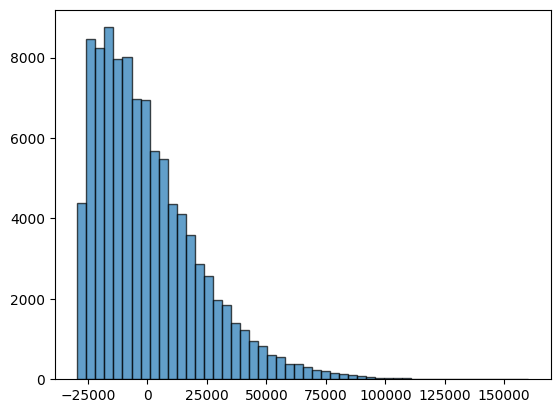

In [15]:
print("平均収支: ", np.mean(result))
print("標準偏差: ", np.std(result))
print("最大値: ", np.max(result))
print("最小値: ", np.min(result))
print("5%点: ", np.percentile(result, 5))
print("95%点: ", np.percentile(result, 95))
plt.hist(np.array(result), bins=50, edgecolor='black', alpha=0.7)
plt.show()